In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('amazon.csv')

In [3]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [4]:
df.shape

(1465, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [6]:
df['discounted_price'] = df['discounted_price'].str.replace('₹','').str.replace(',','').str.replace(' ','')
df['actual_price'] = df['actual_price'].str.replace('₹','').str.replace(',','').str.replace(' ','')

df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors = 'coerce')
df['actual_price'] = pd.to_numeric(df['actual_price'], errors = 'coerce')

print(df[['discounted_price', 'actual_price']].dtypes)

discounted_price    float64
actual_price        float64
dtype: object


In [7]:
df['discount_percentage'] = df['discount_percentage'].str.replace('%','').str.replace(' ','')
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors = 'coerce')

df['rating'] = df['rating'].str.replace(' ','')
df['rating'] = pd.to_numeric(df['rating'], errors = 'coerce')

df['rating_count'] = df['rating_count'].str.replace(',','').str.replace(' ','')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors = 'coerce')

print(df[['discount_percentage', 'rating', 'rating_count']].dtypes)

discount_percentage      int64
rating                 float64
rating_count           float64
dtype: object


In [8]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1464.000000,1463.000000
mean,3125.310874,5444.990635,47.691468,4.096585,18295.541353
std,6944.304394,10874.826864,21.635905,0.291674,42753.864952
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,32.000000,4.000000,1186.000000
50%,799.000000,1650.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4295.000000,63.000000,4.300000,17336.500000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


In [9]:
rating_median = df['rating'].median()
df['rating'] = df['rating'].fillna(rating_median)

rating_count_median = df['rating_count'].median()
df['rating_count'] = df['rating_count'].fillna(rating_count_median)

print("Remaining missing values:")
print(df[['rating', 'rating_count']].isnull().sum())

Remaining missing values:
rating          0
rating_count    0
dtype: int64


In [10]:
df['main_category'] = df['category'].str.split('|').str[0]

print("Top 5 Main Categories:")
print(df['main_category'].value_counts().head())

Top 5 Main Categories:
main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
Name: count, dtype: int64


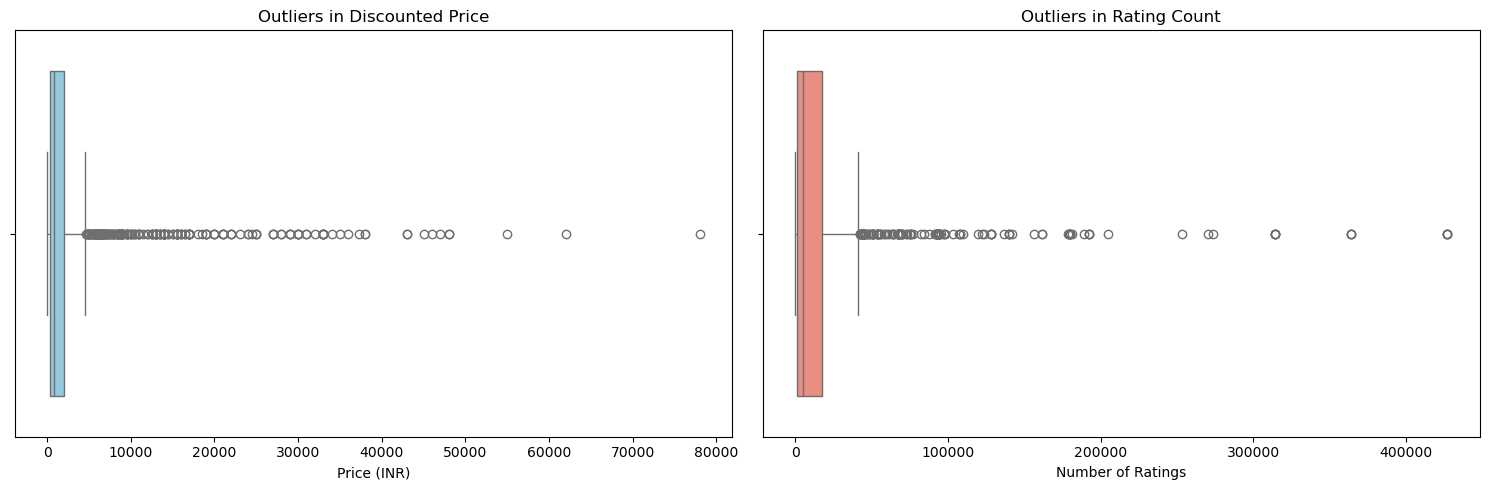

In [11]:
plt.figure(figsize = (15,5))

plt.subplot(1,2,1)
sns.boxplot(x = df['discounted_price'], color = 'skyblue')
plt.title('Outliers in Discounted Price')
plt.xlabel('Price (INR)')

plt.subplot(1,2,2)
sns.boxplot(x = df['rating_count'], color = 'salmon')
plt.title('Outliers in Rating Count')
plt.xlabel('Number of Ratings')

plt.tight_layout()
plt.show()

In [12]:
Q1 = df['discounted_price'].quantile(0.25)
Q3 = df['discounted_price'].quantile(0.75)
IQR = Q3 - Q1 
upper_limit = Q3 + (1.5 * IQR)
print(f"{upper_limit:.2f}")

4510.00


In [13]:
premium_products = df[df['discounted_price'] > upper_limit]
print(f"Total Premium Products (Outliers): {len(premium_products)}")
print("\nTop Categories of Premium Products")
print(premium_products['main_category'].value_counts())

Total Premium Products (Outliers): 217

Top Categories of Premium Products
main_category
Electronics              146
Home&Kitchen              61
Computers&Accessories     10
Name: count, dtype: int64


In [14]:
Q1_rc = df['rating_count'].quantile(0.25)
Q3_rc = df['rating_count'].quantile(0.75)
IQR_rc = Q3_rc - Q1_rc
upper_limit_rc = Q3_rc + (1.5 * IQR_rc)
print(f'{upper_limit_rc:.2f}')

41526.00


In [15]:
viral_products = df[df['rating_count'] > upper_limit_rc]
print(f"Total Viral Products (Outliers): {len(viral_products)}")
print("\n--- Sample of highly reviewed viral products ---")
print(viral_products[['product_name', 'main_category', 'rating_count']].head(5))

Total Viral Products (Outliers): 141

--- Sample of highly reviewed viral products ---
                                         product_name          main_category  \
1   Ambrane Unbreakable 60W / 3A Fast Charging 1.5...  Computers&Accessories   
3   boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...  Computers&Accessories   
8   TP-Link USB WiFi Adapter for PC(TL-WN725N), N1...  Computers&Accessories   
9   Ambrane Unbreakable 60W / 3A Fast Charging 1.5...  Computers&Accessories   
11  boAt Rugged v3 Extra Tough Unbreakable Braided...  Computers&Accessories   

    rating_count  
1        43994.0  
3        94363.0  
8       179691.0  
9        43994.0  
11       94363.0  


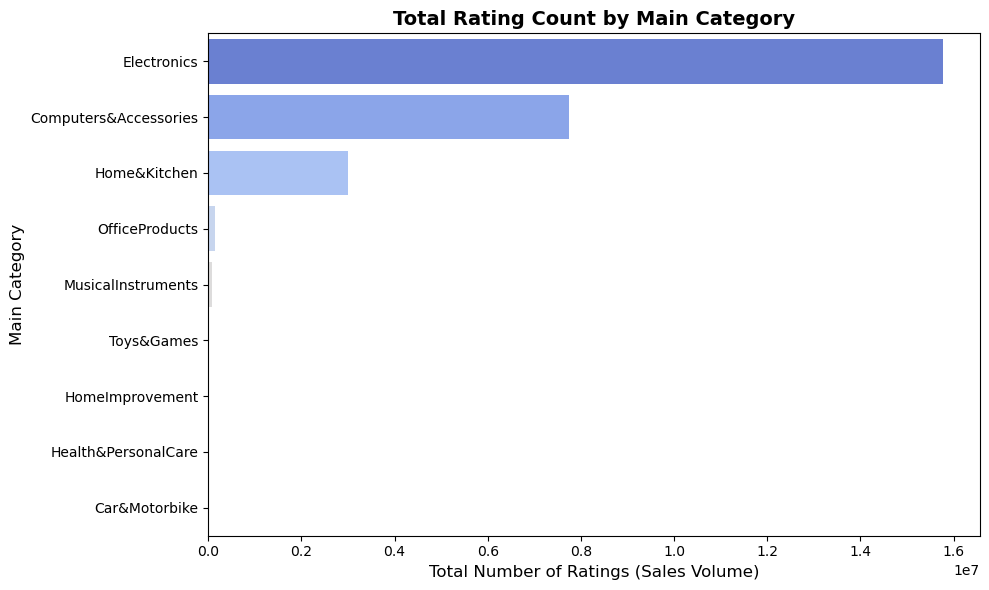

Exact Sales volume (Total Ratings) per category:            main_category  rating_count
0            Electronics    15778848.0
1  Computers&Accessories     7739047.0
2           Home&Kitchen     2991069.0
3         OfficeProducts      149675.0
4     MusicalInstruments       88882.0
5             Toys&Games       15867.0
6        HomeImprovement        8566.0
7    Health&PersonalCare        3663.0
8          Car&Motorbike        1118.0


In [16]:
category_sales = df.groupby('main_category')['rating_count'].sum().sort_values(ascending = False).reset_index()

plt.figure(figsize = (10,6))
sns.barplot(x = 'rating_count', y = 'main_category', data = category_sales, hue = 'main_category', legend = False, palette = 'coolwarm')
plt.title('Total Rating Count by Main Category', fontsize = 14, fontweight = 'bold')
plt.xlabel('Total Number of Ratings (Sales Volume)', fontsize = 12)
plt.ylabel('Main Category', fontsize = 12)

plt.tight_layout()
plt.show()

print(f'Exact Sales volume (Total Ratings) per category: {category_sales}')

In [17]:
underperforming_analysis = df.groupby('main_category').agg(
    total_products = ('product_id', 'count'),
    avg_rating = ('rating', 'mean'),
    avg_discount_pct = ('discount_percentage', 'mean'), 
    total_sales_volume = ('rating_count', 'sum')
).sort_values(ascending = False, by = 'total_sales_volume').reset_index()
underperforming_analysis['avg_rating'] = underperforming_analysis['avg_rating'].round(2)
underperforming_analysis['avg_discount_pct'] = (underperforming_analysis['avg_discount_pct']).round(2)
print("--- Deeper Business Analysis Report ---")
print(underperforming_analysis)

--- Deeper Business Analysis Report ---
           main_category  total_products  avg_rating  avg_discount_pct  \
0            Electronics             526        4.08             50.83   
1  Computers&Accessories             453        4.15             54.02   
2           Home&Kitchen             448        4.04             40.12   
3         OfficeProducts              31        4.31             12.35   
4     MusicalInstruments               2        3.90             46.00   
5             Toys&Games               1        4.30              0.00   
6        HomeImprovement               2        4.25             57.50   
7    Health&PersonalCare               1        4.00             53.00   
8          Car&Motorbike               1        3.80             42.00   

   total_sales_volume  
0          15778848.0  
1           7739047.0  
2           2991069.0  
3            149675.0  
4             88882.0  
5             15867.0  
6              8566.0  
7              3663.0  
8  

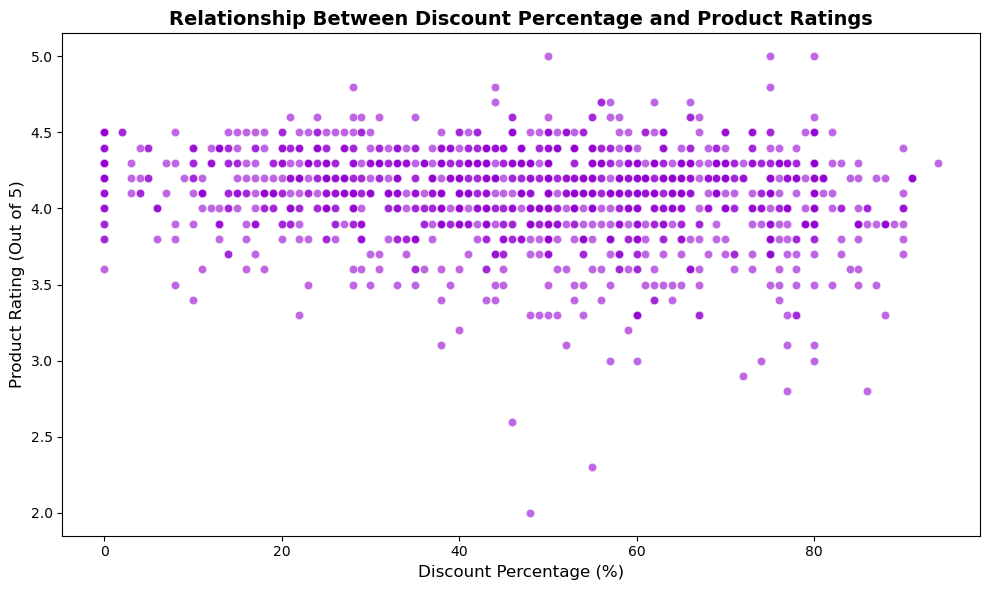

Correlation coefficient: -0.1553


In [18]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'discount_percentage', y = 'rating', data = df, alpha = 0.6, color = 'darkviolet')
plt.title('Relationship Between Discount Percentage and Product Ratings', fontsize = 14, fontweight = 'bold')
plt.xlabel('Discount Percentage (%)', fontsize = 12)
plt.ylabel('Product Rating (Out of 5)', fontsize = 12)

plt.tight_layout()
plt.show()

correlation = df['discount_percentage'].corr(df['rating'])
print(f"Correlation coefficient: {correlation:.4f}")

In [19]:
high_discount_products = df.sort_values(by = 'discount_percentage', ascending = False)[['product_name', 'main_category','discount_percentage','rating']].head(10)
print("--- Top 10 Highest Discounted Products & Their Ratinggs ---")
print(high_discount_products)

--- Top 10 Highest Discounted Products & Their Ratinggs ---
                                           product_name  \
695   rts [2 Pack] Mini USB C Type C Adapter Plug, T...   
368   Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...   
380   Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...   
334   Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...   
372   Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...   
364   Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...   
1026  beatXP Kitchen Scale Multipurpose Portable Ele...   
557   LAPSTER 12pcs Spiral Cable Protectors for Char...   
542   Sounce Protective Case Cover Compatible Boat X...   
407   Sounce Spiral Charger Cable Protector Data Cab...   

              main_category  discount_percentage  rating  
695   Computers&Accessories                   94     4.3  
368             Electronics                   91     4.2  
380             Electronics                   91     4.2  
334             Electronics                   91     4

In [20]:
df['discount_range'] = pd.cut(
    df['discount_percentage'],
    bins = [0,20,40,60,80,100],
    labels = ['0-20% Low', '20-40% Mid', '40-60% High', '60-80% Very High', '80-100% Extreme']
)

discount_analysis = df.groupby('discount_range', observed = False).agg(total_products = ('product_id', 'count'),average_rating = ('rating', 'mean')).reset_index()

print("--- Discount Range vs Average Rating Report ---")
print(discount_analysis)

--- Discount Range vs Average Rating Report ---
     discount_range  total_products  average_rating
0         0-20% Low             131        4.146565
1        20-40% Mid             338        4.126331
2       40-60% High             508        4.079331
3  60-80% Very High             380        4.076053
4   80-100% Extreme              59        3.976271


In [21]:
good_quality_df = df[df['rating'] >= 4.0]
superstar_products = good_quality_df.sort_values(by = 'rating_count', ascending = False)[['product_name', 'main_category', 'rating', 'rating_count', 'discounted_price']].head(10)
print("--- Amazon's Top 10 Superstar Products ---")
print(superstar_products)

--- Amazon's Top 10 Superstar Products ---
                                          product_name main_category  rating  \
47   Amazon Basics High-Speed HDMI Cable, 6 Feet - ...   Electronics     4.4   
65   Amazon Basics High-Speed HDMI Cable, 6 Feet (2...   Electronics     4.4   
12   AmazonBasics Flexible Premium HDMI Cable (Blac...   Electronics     4.4   
684  AmazonBasics Flexible Premium HDMI Cable (Blac...   Electronics     4.4   
352  boAt Bassheads 100 in Ear Wired Earphones with...   Electronics     4.1   
400  boAt Bassheads 100 in Ear Wired Earphones with...   Electronics     4.1   
584  boAt BassHeads 100 in-Ear Wired Headphones wit...   Electronics     4.1   
371  Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...   Electronics     4.1   
370  Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...   Electronics     4.1   
473  Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...   Electronics     4.1   

     rating_count  discounted_price  
47       426973.0             309.0  


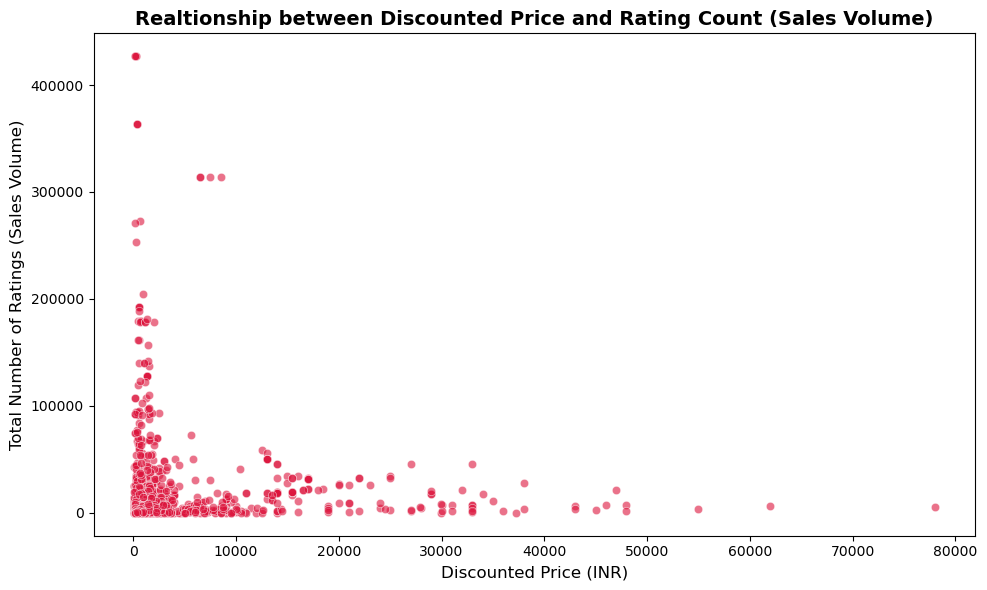

Correlation coefficient between price and Sales Volume: -0.0271


In [22]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'discounted_price', y = 'rating_count', data = df, alpha = 0.6, color = 'crimson')
plt.title('Realtionship between Discounted Price and Rating Count (Sales Volume)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Discounted Price (INR)', fontsize = 12)
plt.ylabel('Total Number of Ratings (Sales Volume)', fontsize = 12)

plt.tight_layout()
plt.show()

price_correlation = df['discounted_price'].corr(df['rating_count'])
print(f"Correlation coefficient between price and Sales Volume: {price_correlation:.4f}")